In [43]:
from google.colab import files

uploaded = files.upload()

Saving titanic_cleaned.csv to titanic_cleaned (2).csv


In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("titanic_cleaned.csv")

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Unknown,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Unknown,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Unknown,Southampton,no,True


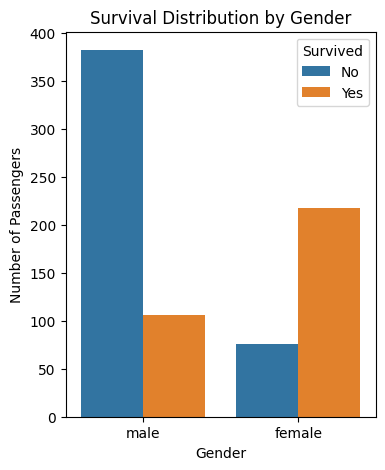

In [45]:
plt.figure(figsize=(4,5))

sns.countplot(data=df, x="sex", hue="survived")

plt.title("Survival Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.legend(title="Survived", labels=["No", "Yes"])

plt.show()

Narrative:
This visualization compares survival outcomes between male and female passengers. It clearly shows that survival was considerably higher among female passengers than male passengers. This chart was selected because a grouped count plot makes the comparison between the two categories easy for a non-technical audience to understand.

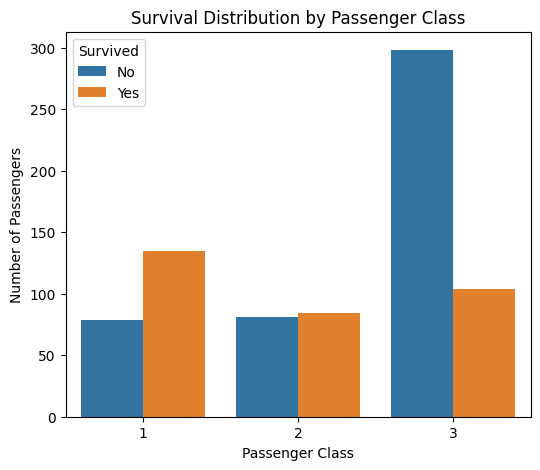

In [46]:
plt.figure(figsize=(6,5))

sns.countplot(data=df, x="pclass", hue="survived")

plt.title("Survival Distribution by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.legend(title="Survived", labels=["No", "Yes"])

plt.show()

Narrative:
This visualization compares survival outcomes across first, second, and third passenger classes. The chart shows that passenger class was associated with different survival outcomes. First-class passengers generally had better survival outcomes compared with passengers in lower classes.

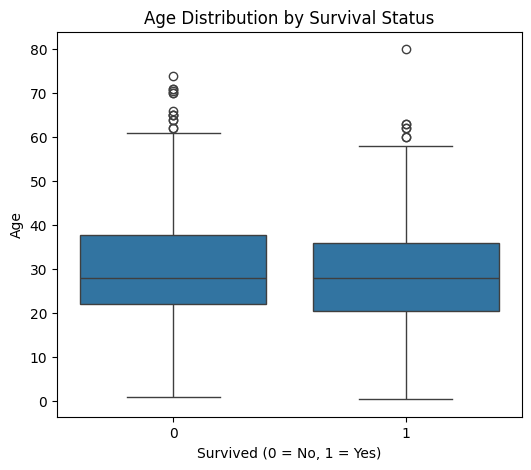

In [47]:
plt.figure(figsize=(6,5))

sns.boxplot(data=df, x="survived", y="age")

plt.title("Age Distribution by Survival Status")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Age")

plt.show()

Narrative:
The box plot compares the age distribution of passengers who survived and those who did not. It helps identify the median age, spread, and possible extreme values in each survival group. This visualization is useful for understanding whether age patterns differed between the two groups.

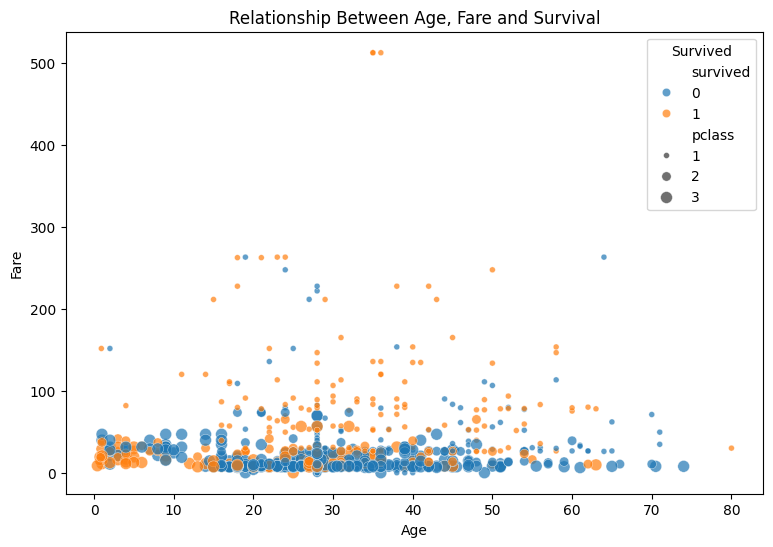

In [48]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x="age",
    y="fare",
    hue="survived",
    size="pclass",
    alpha=0.7
)

plt.title("Relationship Between Age, Fare and Survival")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.legend(title="Survived")

plt.show()

Narrative:
This scatter plot examines the relationship between passenger age and fare while also showing survival status. Passenger class is represented through marker size. The visualization helps reveal how fare, age, class, and survival interacted within the dataset.

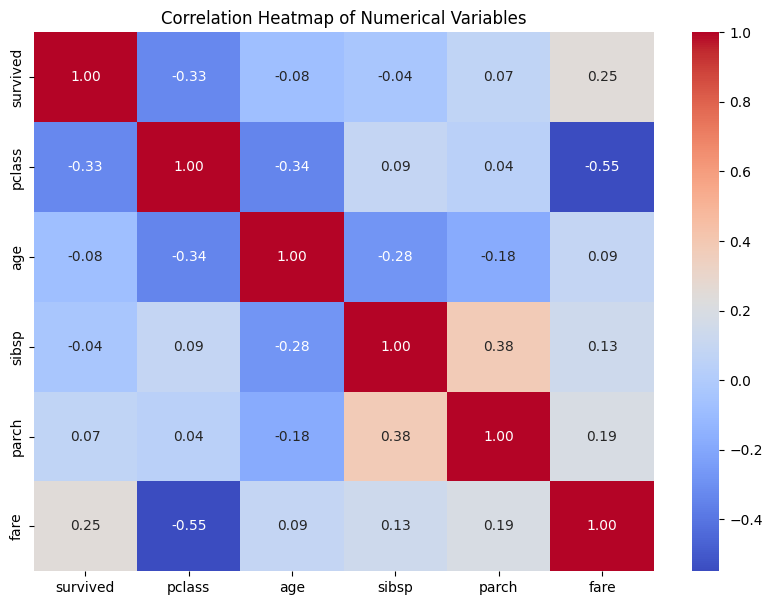

In [49]:
plt.figure(figsize=(10,7))

numeric_df = df.select_dtypes(include=["int64", "float64"])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

Narrative:
The correlation heatmap summarizes relationships among numerical variables. It helps identify variables that move together and variables that have weaker relationships. The visualization provides a quick overview of the numerical structure of the dataset.

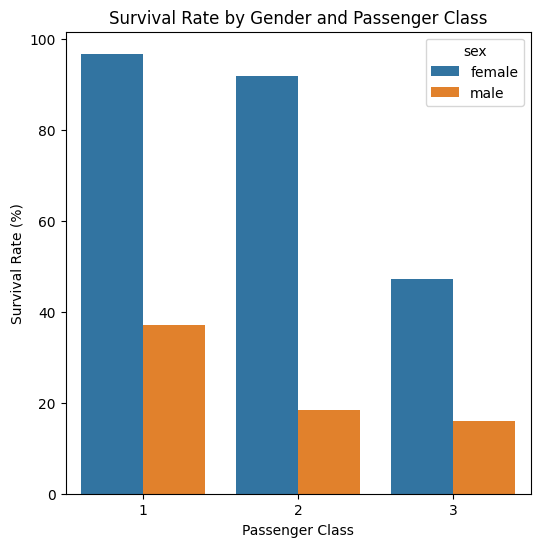

In [50]:
survival_rate = df.groupby(["sex", "pclass"])["survived"].mean() * 100

survival_rate = survival_rate.reset_index()

plt.figure(figsize=(6,6))

sns.barplot(
    data=survival_rate,
    x="pclass",
    y="survived",
    hue="sex"
)

plt.title("Survival Rate by Gender and Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")

plt.show()

Narrative:
This visualization combines gender and passenger class to provide a more detailed view of survival rates. It demonstrates that survival was influenced by multiple passenger characteristics rather than a single factor. This makes the visualization particularly useful for storytelling.

In [51]:
print("Overall Survival Rate:")
print(df["survived"].mean() * 100)

Overall Survival Rate:
41.35723431498079


In [52]:
print("Survival Rate by Gender:")
print(df.groupby("sex")["survived"].mean() * 100)

Survival Rate by Gender:
sex
female    74.061433
male      21.721311
Name: survived, dtype: float64


In [53]:
print("Survival Rate by Passenger Class:")
print(df.groupby("pclass")["survived"].mean() * 100)

Survival Rate by Passenger Class:
pclass
1    63.084112
2    50.909091
3    25.870647
Name: survived, dtype: float64


In [54]:
print("Survival Rate by Gender and Class:")
print(df.groupby(["sex", "pclass"])["survived"].mean() * 100)

Survival Rate by Gender and Class:
sex     pclass
female  1         96.774194
        2         91.780822
        3         47.244094
male    1         37.190083
        2         18.478261
        3         16.000000
Name: survived, dtype: float64
